<div style="border:4px solid red">

For all homework blocks that have numerical answers, name the variable hw followed by the homework number.

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import special

# Review

We started with the Sommerfeld diffraction integral

$E(P_o) = \frac{z}{j\lambda} \int_{\Sigma} E_{inc} \frac{e^{jkr_{01}}}{r_{01}^2} dx' dy'$

We then made the Fresnel approximation:
- keep first two terms of the binomial expansion for the argument of the complex exponential
- $r_{01}=z$

The resulting Fresnel diffraction equation is

$E(P_0) = \frac{e^{jkz}}{j\lambda z} 
\iint_{\Sigma} E(x',y') 
\exp\left[j\frac{k}{2z}\left((x-x')^2 + (y-y')^2\right)\right]
dx' dy'$


## Fraunhofer Approximation

Expand quadratic term
$\exp \left(j\frac{k}{2z} \left[ (x-x')^2 + (y-y')^2 \right] \right)$

$=\exp \left( j\frac{\pi}{\lambda \, z} \left[ x^2 + y^2 - 2xx' - 2yy' + x'^2 + y'^2 \right] \right)$

$=\exp \left( j\frac{\pi}{\lambda \, z} \left[ x^2 +y^2 \right] \right) \, 
  \exp \left( j\frac{\pi}{\lambda \, z} \left[ x'^2 + y'^2 \right] \right) \,
  \exp \left( j\frac{\pi}{\lambda \, z} \left[- 2xx' - 2yy' \right] \right)$

We want to neglect the term with $x'^2 + y'^2$.  We can do this when the value is much less than a rotation or 

$\frac{\pi}{\lambda \, z} \left[ x'^2 + y'^2 \right] \ll 2 \pi$

or

$z \gg \frac{x'^2 + y'^2}{2\lambda}$

The Fraunhofer diffraction integral is

$E(x,y,z) =
\frac{e^{jkz}}{j\lambda z} e^{j\frac{k}{2z}(x^2+y^2)}
\iint_{\Sigma} E(x',y')
\exp\left[-j\frac{k}{z}(xx' + yy')\right] dx' dy'$

or


$E(x,y,z) = 
\frac{e^{jkz}}{j\lambda z} e^{j\frac{k}{2z}(x^2+y^2)}
\int E(x',y') \exp\left[-j\frac{k}{z} (xx') \right] dx'
\int \exp\left[-j\frac{k}{z}(yy')\right] dy'$


This equation is similar to the Fourier transform integral.  As a reminder, here is the Fourier transform integral equation

$ F(\omega) =\int_{-\infty}^{\infty} f(t) \, e^{-j 2 \pi f t} dt$

The Fraunhofer integral consists of two Fourier transform integrals multiplied together.

$\int f(t) \, e^{-j 2 \pi f t} dt \equiv \int E(x') \exp \left[-j\frac{k}{z} (xx') \right] dx'$

If $f(t) = E(x')$, $t=x'$, and $2 \pi f = \frac{kx}{z}$.  We use the substitution of

$2 \pi f = \frac{2 \pi x}{\lambda z}$

or 

$f_x = \frac{x}{\lambda z}$

We can also do this for the y integral to get

$f_y = \frac{y}{\lambda z}$

<div style="border:4px solid red">

**HW1:** A plane wave with a wavelength of $\lambda=600nm$ is incident onto an infinite  slit with a width of 1mm.  To use Fraunhofer diffraction the distance away from the aperture needs to be $z \gg \frac{x'^2 + y'^2}{2\lambda}$.  For the $\gg$ condition, we will use a factor of 10, resulting in $z > \frac{x'^2 + y'^2}{20\lambda}$.
What is the required distance away from the aperture in units of m?

In [21]:
# HW1: minimum Fraunhofer distance using the equation provided in the prompt
wavelength = 600e-9          # m
slit_width = 1e-3            # m
x_prime_max = slit_width / 2 # m, edge of the slit
y_prime_max = 0.0            # m, infinite slit assumption in y

hw1 = (x_prime_max**2 + y_prime_max**2) / (20 * wavelength)
print(f"hw1 = {hw1:.6f} m")

hw1 = 0.020833 m


<div style="border:4px solid red">

**HW2:** A plane wave with a wavelength of $\lambda=600nm$ is incident onto an infinite slit with a width of 1mm. Create a line plot of the normalized irradiance at a distance of $z=60m$. What is the FWHM (full width at half maximum) of the electric field in units of meters?  Name the FWHM as hw2.

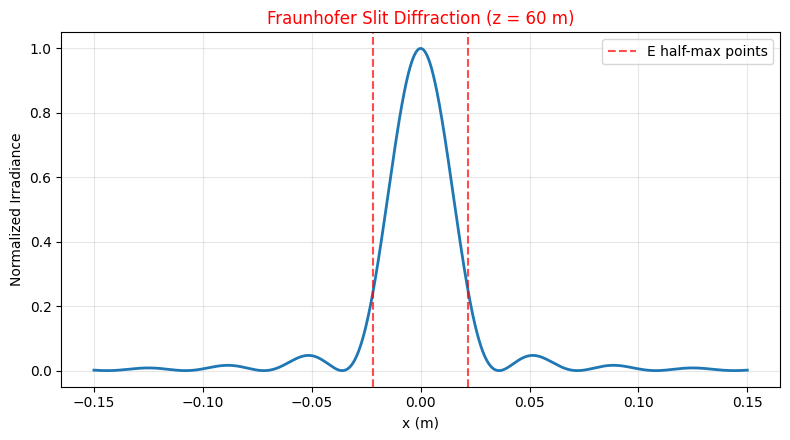

hw2 = 0.043442 m


In [22]:
# HW2: Fraunhofer diffraction from a 1D slit (width = 1 mm) at z = 60 m
wavelength = 600e-9   # m
z = 60.0              # m
slit_width = 1e-3     # m (full slit width)

# Observation coordinate in the diffraction plane (meters)
x = np.linspace(-0.15, 0.15, 200001)

# Normalized electric field amplitude and irradiance
E_norm = np.abs(np.sinc((slit_width * x) / (wavelength * z)))
I_norm = E_norm**2

# FWHM of electric field: find where E_norm crosses 0.5 on each side of x=0
half = 0.5
center_idx = np.argmin(np.abs(x))

# Find bracketing indices around the half-max crossings
right_idx = center_idx + np.where(E_norm[center_idx:] <= half)[0][0]
left_idx = np.where(E_norm[:center_idx] <= half)[0][-1]

# Use interpolation to get more accurate crossing positions
x_left = np.interp(
    half,
    E_norm[left_idx:center_idx + 1],
    x[left_idx:center_idx + 1],
)
x_right = np.interp(
    half,
    E_norm[center_idx:right_idx + 1][::-1],
    x[center_idx:right_idx + 1][::-1],
)

hw2 = x_right - x_left

plt.figure(figsize=(8, 4.5))
plt.plot(x, I_norm, linewidth=2)
plt.axvline(x_left, color='r', linestyle='--', alpha=0.7, label='E half-max points')
plt.axvline(x_right, color='r', linestyle='--', alpha=0.7)
plt.xlabel('x (m)')
plt.ylabel('Normalized Irradiance')
plt.title('Fraunhofer Slit Diffraction (z = 60 m)', color='red')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"hw2 = {hw2:.6f} m")

## Fraunhofer Slit Diffraction

A plane wave is incident onto a slit.  The slit transmits the electric field inside of the slit and blocks it outside of the slit as given by

$T(x) =
\begin{cases}
1 & |x| \le a \\
0 & \text{else}
\end{cases}$

Since a plane wave is incident onto the slit, the electric field just past the slit is given by 

$E(x,y, z=0^+) =
\begin{cases}
E_o & |x| \le a \\
0 & \text{else}
\end{cases}$

This is a rect function. The rect function is defined as 

$\text{rect}(x) =
\begin{cases}
1 & |x| < \frac{1}{2} \\
0 & |x| \ge \frac{1}{2}\
\end{cases}$

## Basic Fourier Transform Relations

<details open>
<summary>Click to collapse</summary>

If $f(x) \leftrightarrow F(f)$:

-   $K f(x) \leftrightarrow K F(f)$
-   $f(ax) \leftrightarrow \frac{1}{|a|} F\!\left(\frac{f}{a}\right)$
-   $f(x-x_0) \leftrightarrow F(f)e^{-j2\pi f x_0}$
-   $e^{j2\pi f_0 x} f(x) \leftrightarrow F(f-f_0)$

</details>


## Fourier Transform Pairs
<details open>
<summary>Click to collapse</summary>

| Function | Fourier Transform |
|-----------|------------------|
| $\delta(x)$ | $1$ |
| $A$ | $2\pi A\,\delta(f)$ |
| $\cos(\omega_0 x)$ | $\pi[\delta(f-\omega_0)+\delta(f+\omega_0)]$ |
| $\sin(\omega_0 x)$ | $j\pi[\delta(f-\omega_0)-\delta(f+\omega_0)]$ |
| $\text{rect}(x)$ | $\text{sinc}(f)$ |
| $\Lambda(x)$ | $\text{sinc}^2(f)$ |
| $\text{circ}(r/R)$ | $\pi R^2 \dfrac{J_1(2\pi R f)}{2\pi R f}$ |
| $e^{-\pi x^2}$ | $e^{-\pi f^2}$ |
| $e^{j\pi x^2}$ | $e^{j\pi/4} e^{-j\pi f^2}$ |
| $\sum_{n=-S}^{S}\delta(x-n)$ | $\dfrac{\sin(M\pi f)}{\sin(\pi f)}$, $M=2S+1$ |
| $\sum_{n=-\infty}^{\infty}\delta(x-n)$ | $\sum_{n=-\infty}^{\infty}\delta(f-n)$ |


$\text{rect}(x) = \begin{cases}
1 & |x| \le \frac{1}{2} \\
0 & \text{otherwise}
\end{cases}$

$\text{sinc}(x)=\frac{\sin (\pi x)}{\pi x}$

$\Lambda(x) = \begin{cases}
1-|x| & |x| \le 1 \\
0 & \text{otherwise}
\end{cases}$

$\text{circ}\left(\sqrt{x^2 + y^2}\right) = \begin{cases}
1 & \sqrt{x^2 + y^2} \le 1 \\
0 & \text{otherwise}
\end{cases}$

$\int_{-\infty}^{\infty} \mathrm{sinc}(x)\, dx = 1$

$\int_{-\infty}^{\infty} \mathrm{sinc}^2(x)\, dx = 1$

$\int_{0}^{\infty} \left| \frac{J_1(x)}{x} \right|^2 dx = \frac{4}{3\pi}$

$\int_{0}^{\infty} x \left| \frac{J_1(x)}{x} \right|^2 dx = \frac{1}{2}$


</details>

<div style="border:4px solid red">

**HW3:** A plane wave of intensity $10 mW/cm^2$ and wavelength $\lambda=600 nm$ is incident onto a rectangular slit of dimensions $1mm X 0.2mm$. Plot the normalized diffraction pattern at the plane $z=2m$. Create a grayscale image plot.  What is the FWHM in the x-direction in units of meters?

hw3 = 1.448048e-03 m


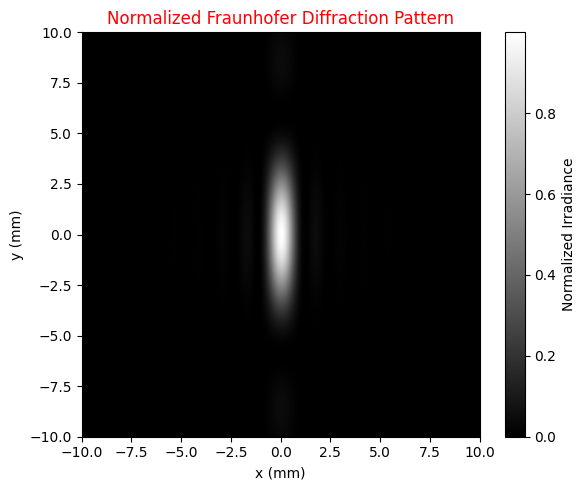

In [28]:
I_0 = 100  # W/m^2, assuming 10 mW power over 1 cm^2 area
l = 600e-9          # m
z = 2.00              # m
slit_x = 1e-3
slit_y = 0.2e-3

x = np.linspace(-0.01, 0.01, 2000)  # m, observation points in x
y = np.linspace(-0.01, 0.01, 2000)  # m, observation points in y


E_norm_x = np.abs(np.sinc((slit_x * x) / (l * z)))
I_norm_x = E_norm_x**2
E_norm_y = np.abs(np.sinc((slit_y * y) / (l * z)))
I_norm_y = E_norm_y**2

I_norm_2D = np.outer(I_norm_y, I_norm_x)

# FWHM of the electric field amplitude in x (E_norm_x = 0.5)
half = 0.5
center_idx = np.argmin(np.abs(x))

left_idx = np.where(E_norm_x[:center_idx] <= half)[0][-1]
right_idx = center_idx + np.where(E_norm_x[center_idx:] <= half)[0][0]

x3_left = np.interp(half, E_norm_x[left_idx:center_idx + 1], x[left_idx:center_idx + 1])
x3_right = np.interp(
    half,
    E_norm_x[center_idx:right_idx + 1][::-1],
    x[center_idx:right_idx + 1][::-1]
)

hw3 = x3_right - x3_left
print(f"hw3 = {hw3:.6e} m")

plt.figure(figsize=(6, 5))
plt.imshow(
    I_norm_2D,
    extent=[x.min()*1e3, x.max()*1e3, y.min()*1e3, y.max()*1e3],
    origin='lower',
    cmap='gray',
    aspect='auto'
)
plt.colorbar(label='Normalized Irradiance')
plt.xlabel('x (mm)')
plt.ylabel('y (mm)')
plt.title('Normalized Fraunhofer Diffraction Pattern', color='red')
plt.tight_layout()
plt.show()

<div style="border:4px solid red">

**HW4:** A plane wave of intensity $10 mW/cm^2$ and wavelength $\lambda=600 nm$ is incident onto a rectangular slit of dimensions $1mm X 0.2mm$. Plot the normalized diffraction pattern at the plane $z=2m$.  What is the FWHM in the y-direction in units of meters?

In [29]:
center_idx = np.argmin(np.abs(y))

left_idx = np.where(E_norm_y[:center_idx] <= half)[0][-1]
right_idx = center_idx + np.where(E_norm_y[center_idx:] <= half)[0][0]

y3_left = np.interp(half, E_norm_y[left_idx:center_idx + 1], y[left_idx:center_idx + 1])
y3_right = np.interp(
    half,
    E_norm_y[center_idx:right_idx + 1][::-1],
    y[center_idx:right_idx + 1][::-1]
)

hw4 = y3_right - y3_left
print(f"hw4 = {hw4:.6e} m")

hw4 = 7.240254e-03 m


<div style="border:4px solid red">

**HW5:** A plane wave of intensity $10 mW/cm^2$ and wavelength $\lambda=600 nm$ is incident onto a rectangular slit of dimensions $1mm X 0.2mm$. What is the peak irradiance in units of $W/m^2$?

In [32]:
I_peak = I_0 * ((slit_x * slit_y) / (l * z))**2
print(f"Peak Irradiance at center: {I_peak:.2f} W/m^2")
hw5 = I_peak

Peak Irradiance at center: 2.78 W/m^2


There are various forms of RF antenna dishes.  The basic form is a horn antenna aimed at the metallic dish.  The main difference are the feed horn.

<img src="antennas.png" width="500">

Here is an off-axis feed antenna

<img src="off_axis.jpg" width="300">

Here is a center feed

<img src="dish_feed.jpg" width="300">

Here is an antenna dish with a reflector

<img src="parabolic_feed.jpg" width="300">

The antenna creates a uniform plane wave with an aperture that is a circle and often also has a center block.  

<div style="border:4px solid red">

**HW6:** A satellite dish has a diameter of 3.5m, an f#=0.38, and operate in the C-band (f=5GHz). Notice the f# of a satellite dish is
much smaller than most optical lens systems. This is because the dish is parabolic and only operates at a very small field of view. 100W of power is uniformly illuminated over the dish.  What is the FWHM of the diffraction pattern at the satelite in units of meters? Use a distance between the satellite dish and the satellite of 36,000km.  Treat the antenna as a uniform plane wave across a circle with a diameter of 3.5m.

$E(r)=\text{circ}(r/R) \Longrightarrow E(f)=\pi R^2 \dfrac{J_1(2\pi R f)}{2\pi R f}$ 

with $f=\frac{r}{\lambda z}$

<div style="border:4px solid red">

**HW7:** A satellite dish has a diameter of 3.5m, an f#=0.38, and operate in the C-band (f=5GHz). Notice the f# of a satellite dish is
much smaller than most optical lens systems. This is because the dish is parabolic and only operates at a very small field of view. 100W of power is uniformly illuminated over the dish. Use a distance between the satellite dish and the satellite of 36,000km.  Treat the antenna as a uniform plane wave across a circle with a diameter of 3.5m. What is the peak irradiance at the satelite in units of $\frac{W}{m^2}$?

<details open>
<summary>Click to collapse</summary>

$E(f_r)=\pi R^2 \dfrac{J_1(2\pi R f_r)}{2\pi R f_r}$

$R=1.75$

$f_r=\frac{r}{\lambda z}$

$E(r)= E_1 \dfrac{J_1(2\pi 1.75 \frac{r}{\lambda z})}{2\pi 1.75 \frac{r}{\lambda z}}$

$E(r)= E_2 \dfrac{J_1(val*r)}{r}$ 

with $val=\frac{2\pi 1.75}{\lambda z}$

$I(r)= I_o \dfrac{J_1^2(val*r)}{r^2}$

$P=I_o \int_0^{2 \pi}  d\phi \int_0^{\infty} \dfrac{J_1^2(val*r)}{r} dr$

$u=val*r$

$r=\frac{1}{val} u$

$du=val * dr$

$dr=\frac{1}{val} du$

$P=\left( I_o \right) \left( 2 \pi \right) \int_0^{\infty} \dfrac{J_1^2(u)}{\frac{1}{val} u} \frac{1}{val} du$

$P=\left( I_o \right) \left( 2 \pi \right) \int_0^{\infty} \dfrac{J_1^2(u)}{u} du$

$P=\left( I_o \right) \left( 2 \pi \right) \left( \frac{1}{2} \right)$

$100=\left( I_o \right) \left( \pi \right)$

$I_o=\frac{100}{\pi}$

$I(r)= \frac{100}{\pi} \left( \dfrac{J_1(val*r)}{r} \right)^2$

$I(r)= \frac{100}{\pi} val^2\left( \dfrac{J_1(val*r)}{val*r} \right)^2$

$I_{max}= \frac{100*val^2}{\pi} \left( \frac{1}{4} \right)$


<div style="border:4px solid red">

**HW8:** A satellite dish has a diameter of 3.5m, an f#=0.38, and operate in the C-band (f=5GHz). Notice the f# of a satellite dish is
much smaller than most optical lens systems. This is because the dish is parabolic and only operates at a very small field of view. 100W of power is uniformly illuminated over the dish.  Create a polar plot of the diffraction pattern.  What is the angular FWHM in units of degrees? Treat the antenna as a uniform plane wave across a circle with a diameter of 3.5m.

The power outside of the central beam are called sidelobes.

<img src="Sidelobes.svg" width="500">

<div style="border:4px solid red">

**HW9:** A satellite dish has a diameter of 3.5m, an f#=0.38, and operate in the C-band (f=5GHz). 100W of power is uniformly illuminated over the dish.  What is the maximum sidelobe irradiance in units of $W/m^2$? Treat the antenna as a uniform plane wave across a circle with a diameter of 3.5m.

<div style="border:4px solid red">

**HW10:** A satellite dish has a diameter of 3.5m, an f#=0.38, and operates in the C-band (f=5GHz). The feed is modeled as a block in the center of the circular aperture.  It is called an obscuration.  What diameter of the obscuration in units of meters changes the FWHM by 10%? Use a distance between the satellite dish and the satellite of 36,000km.

Main points:
- Solve for the diffracted field of the aperture and obscuration separate
- Subtract the obscuration field from the aperture field (Not irradiances)
- Need to watch the amplitude terms

$E_a(f_r)=\pi R_a^2 \dfrac{J_1(2\pi R_a f_r)}{2\pi R_a f_r}$

$E_o(f_r)=\pi R_o^2 \dfrac{J_1(2\pi R_o f_r)}{2\pi R_o f_r}$

$E_{tot}(f_r)=\pi R_a^2 \dfrac{J_1(2\pi R_a f_r)}{2\pi R_a f_r} - \pi R_o^2 \dfrac{J_1(2\pi R_o f_r)}{2\pi R_o f_r}$


<div style="border:4px solid red">

**HW11:** A satellite dish operates in the C-band (f=5GHz). The electric field amplitude across the antenna dish plane is Gaussian with an equation given by $E(r')=0.1 * \exp \left(-(r')^2 \right)$.  Plot the normalized linear diffraction pattern at a distance of 36,000km for both the Gaussian illumination and a uniformly illuminated dish (with a dish diameter of 3.5m). What is the FWHM of the Gaussian illuminated dish in units of meters?  Ignore any clipping of the Gaussian illumination.

Here is the profile of the Gaussian illumination out to a radius of 1.75m (the dish size).  Notice that at a radius of 1.75m the strength of the illumination is fairly small.

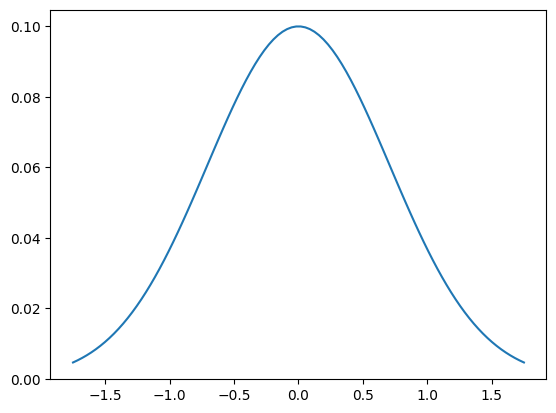

In [24]:
r_dish=np.linspace(-1.75, 1.75, 100)
Edish=0.1*np.exp(-1*r_dish**2)

plt.plot(r_dish, Edish)
plt.show()

In [25]:
#Code for problem 11